In [8]:
import pandas as pd
from pandas import IndexSlice
import numpy as np
import matplotlib.pyplot as plt

from config import PATHS

In [2]:
ALPHA: float = 0.05
ROC_AUC_THRESH: float = 0.75
MODEL_NAMES: list[str] = ['CNN', 'ensemble']

In [3]:
models = pd.read_pickle(PATHS.per_model_comparison_table.pickle)
cycle_extr = pd.read_pickle(PATHS.cycle_extraction_metrics_per_ptnt_table.pickle)
circ_comp = pd.read_pickle(PATHS.circular_comparison_per_ptnt_table.pickle)
combined = cycle_extr.join(circ_comp)
# combined.head()

In [4]:
# Check that the patient's seizures are phase locked with features
szrs_mean_angle_deg = combined[('seizures', 'mean_angle_deg')]
t = combined[[('seizures', 'p_rayleigh_bh')]].copy()
t[('seizures', 'significant')] = t[('seizures', 'p_rayleigh_bh')] < ALPHA
t[('seizures', 'mean_angle_deg')] = szrs_mean_angle_deg
# t

In [5]:
for model_name in MODEL_NAMES:
    # Check that the model has appropriate ROC AUC
    roc_auc_by_ptnt = models.loc[IndexSlice[:, model_name], ('roc_auc', 'test')].droplevel(1)
    roc_auc = t.index.get_level_values(0).map(roc_auc_by_ptnt)  # Broadcast to entire index
    t[(model_name, 'roc_auc')] = roc_auc
    t[(model_name, 'roc_auc_met')] = roc_auc >= ROC_AUC_THRESH

    # Check if FPs per model are phase locked with features
    p_ray = combined[(f'{model_name} FPs', 'p_rayleigh_bh')]
    t[(model_name, 'p_rayleigh_bh')] = p_ray
    t[(model_name, 'significant')] = p_ray < ALPHA

    # Calculate mean angle difference
    t[(model_name, 'observed_diff')] = combined[(f'seizures vs {model_name} FPs', 'observed_diff')]

    t[(model_name, 'qualified')] = (
            t[('seizures', 'significant')] &
            t[(model_name, 'roc_auc_met')] &
            t[(model_name, 'significant')]
    )

# t

In [6]:
ens_qualified = t[t[('ensemble', 'qualified')]].drop(columns=['CNN'])
cnn_qualified = t[t[('CNN', 'qualified')]].drop(columns=['ensemble'])
# ens_qualified

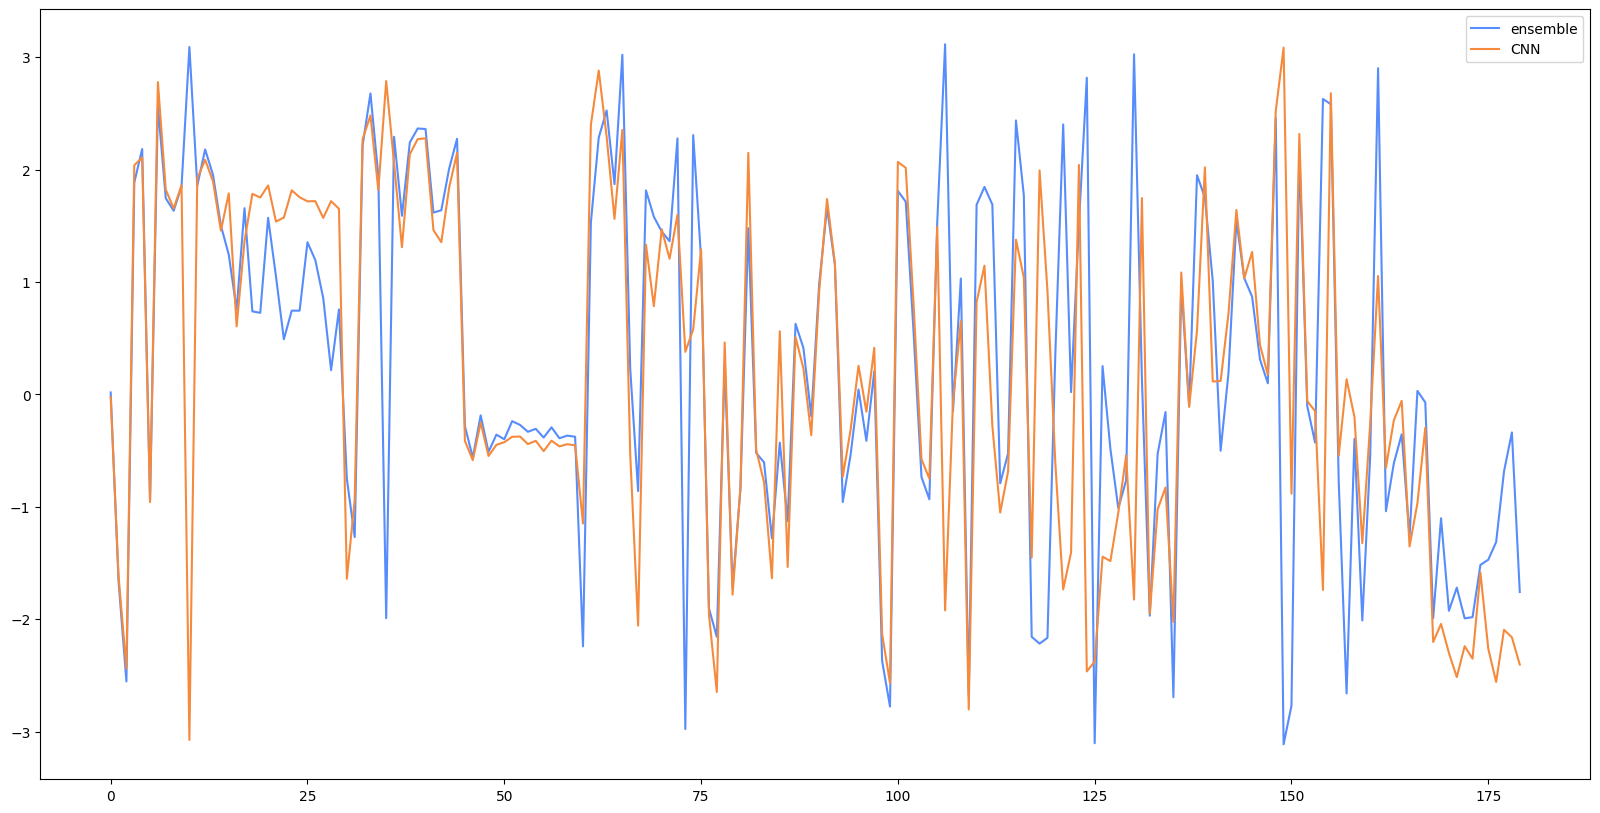

In [10]:
fig, ax = plt.subplots(figsize=(20, 10))

x = np.arange(len(t))
plt.plot(x, t[('ensemble', 'observed_diff')].values, label='ensemble')
plt.plot(x, t[('CNN', 'observed_diff')].values, label='CNN')
plt.legend(loc='upper right')